In [106]:
from collections import Counter
from datetime import datetime, timezone
import inspect
import json
import logging
import matplotlib.pyplot as plt
import mlflow
import nltk
from nltk.corpus import stopwords
import numpy as np
import os
from pathlib import Path
import pandas as pd
import random
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_curve
import shutil
import torch
from torch import nn, optim
from torch.amp import GradScaler, autocast
from torch.cuda import Event
import torch.nn.functional as F
from torch.nn.utils import clip_grad_norm_
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts, CosineAnnealingLR, OneCycleLR, ReduceLROnPlateau
from torch.utils.data import Dataset, DataLoader
from torchmetrics.classification import BinaryAccuracy, BinaryPrecision, BinaryRecall, BinaryF1Score, AUROC, AveragePrecision, PrecisionRecallCurve
from tqdm.notebook import tqdm
import warnings
import zipfile
warnings.filterwarnings("ignore", message=".*Pickle or CloudPickle.*")
nltk.download('stopwords', quiet=True)

True

In [75]:
%load_ext requirements

The requirements extension is already loaded. To reload it, use:
  %reload_ext requirements


In [76]:
class SystemConfig:
    IS_DETERMINISTIC = False
    _PROJECT_ROOT = Path.cwd()  # research/ folder
    _DB_PATH = _PROJECT_ROOT / "mlflow-quora-questions-pairs.db"
    MLFLOW_TRACKING_URI = f"sqlite:///{_DB_PATH.as_posix()}"
    NEXT_LINE_COUNTER = 180
    SEED = 28
    USED_SCALER = False
    NEXT_LINE_COUNTER = 180
    @staticmethod
    def get_device():
        '''
        Detects the best available device for PyTorch.
        Priority: TPU -> GPU (CUDA) -> CPU
        '''
        # 1. Check for TPU (requires torch_xla)
        try:
            import torch_xla.core.xla_model as xm
            device = xm.xla_device()
            print(f">>> Using TPU: {device}")
        except ImportError:
            # 2. Check for GPU (CUDA)
            if torch.cuda.is_available():
                device = torch.device("cuda")
                print(f">>> Using GPU: {torch.cuda.get_device_name(0)}")
            # 3. Fallback to CPU
            else:
                device = torch.device("cpu")
                print(">>> Using CPU")
                
        return device
    DEVICE = get_device.__func__()

    @classmethod
    def to_dict(cls):
        return {
            k.lower(): v for k, v in cls.__dict__.items()
            if not k.startswith("_")
            and not inspect.isroutine(v)   # functions, methods
            and not isinstance(v, (classmethod, staticmethod))
        }

>>> Using GPU: NVIDIA GeForce GTX 1650


In [77]:
class PathConfig:
    ROOT_DIR = Path().cwd()
    EMB_DIR = ROOT_DIR.parent.parent
    EMB_PATH = EMB_DIR / "glove.6B.100d.txt"
    ARTIFACT_DIR = ROOT_DIR / "artifacts"
    REQ_TEXT = ROOT_DIR / "requirements.txt"
    REQ_SCRIPT = ROOT_DIR / "requirements.py"
    MODEL_SCRIPT = ROOT_DIR / "model_architecture.py"
    NOTEBOOK_PATH = ROOT_DIR / "LSTM-attention-train.ipynb"
    DATA_DIR = ROOT_DIR / "data"
    MLFLOW_DIR = ROOT_DIR / "mlruns"
    CHECKPOINT_DIR = ARTIFACT_DIR / "checkpoint"
    CONFIG_PATH = ARTIFACT_DIR / "configs.json"
    HISTORY_PATH = ARTIFACT_DIR / "training_history.json"
    VOCABS_PATH = ARTIFACT_DIR / "vocabs.json"
    LABEL_MAPPING_PATH = ARTIFACT_DIR / "label_mapping.json"
    TRAIN_ZIP_PATH = DATA_DIR / "train.csv.zip"
    TRAIN_CSV_PATH = DATA_DIR / "train.csv"
    @classmethod
    def to_dict(cls):
        return {
            k.lower(): v for k, v in cls.__dict__.items()
            if not k.startswith("_")
            and not inspect.isroutine(v)   # functions, methods
            and not isinstance(v, (classmethod, staticmethod))
        }

    @classmethod
    def update_requirements(cls):
        from IPython import get_ipython
        ipython = get_ipython()
        if ipython:
            ipython.run_line_magic('updatereqs', str(cls.NOTEBOOK_PATH))

In [78]:
class TokenConfig:
    PAD_TOKEN = '<PAD>'
    UNK_TOKEN = '<UNK>'
    PAD_IDX = 0
    UNK_IDX = 1
    LOWERCASE = True
    UPPERCASE = False
    MAX_LENGTH = 50
    VOCAB_SIZE = 20000
    @classmethod
    def to_dict(cls):
        return {
            k.lower(): v for k, v in cls.__dict__.items()
            if not k.startswith("_")
            and not inspect.isroutine(v)   # functions, methods
            and not isinstance(v, (classmethod, staticmethod))
        }

In [79]:
class LoaderConfig:
    BATCH_SIZE = 128
    NUM_WORKERS = 0
    IS_PIN_MEMORY = True
    @classmethod
    def to_dict(cls):
        return {
            k.lower(): v for k, v in cls.__dict__.items()
            if not k.startswith("_")
            and not inspect.isroutine(v)   # functions, methods
            and not isinstance(v, (classmethod, staticmethod))
        }

In [80]:
class ModelConfig:
    MODEL_TYPE = "LSTM_attention"
    ATTENTION_TYPE = "OneHead-Bahdanau"
    # Embedding
    LAYER_NORM_EMB = True
    FREEZE_TOKEN_EMBEDDING = True
    TOKEN_EMBEDDING = "gloVe-6B-100d"
    EMB_DIM = 100
    EMB_DP = 0.2
    # Model
    LOSS = "Consrative Loss"
    BIDIRECTIONAL = True
    DROPOUT = 0.5
    HIDDEN_DIM = 256
    ATTENTION_DROPOUT = 0.2
    LAYER_NORM_LSTM = False
    LAYER_NORM_ATTENTION = True
    ATTENTION_PROJECTION = False
    if ATTENTION_PROJECTION:
        PROJECT_DIM = HIDDEN_DIM // 2
    MARGIN = 1.0
    MASK_FILL_NUM = -1e10
    SIAMESE_SIMILARITY_PARM = ["Euclidean Distance"]
    NUM_LAYERS = 2
    SKIP_CONNECTION = False
    @classmethod
    def to_dict(cls):
        return {
            k.lower(): v for k, v in cls.__dict__.items()
            if not k.startswith("_")
            and not inspect.isroutine(v)   # functions, methods
            and not isinstance(v, (classmethod, staticmethod))
        }

In [81]:
class TrainConfig:
    LOSS = "Consrative Loss"
    CLIP_NORM = 1.5
    EARLY_STOP_METRIC = "loss"
    CHECKPOINT_METRIC = "F1Score"
    if CHECKPOINT_METRIC == "loss":
        CHECKPOINT_MODE = "min"
    else:
        CHECKPOINT_MODE = "max"
    SCHEDULER_METRIC = "loss"
    EARLY_STOP_MIN_DELTA = 1e-4
    if EARLY_STOP_METRIC in ["F1Score", "Accuracy", "Precision", "Recall"]:
        EARLY_STOP_MODE = "max"
    elif EARLY_STOP_METRIC == "loss":
        EARLY_STOP_MODE = "min"
    EARLY_STOP_PATIENCE = 3
    EPOCHS = 50
    LEARNING_RATE = 3e-4
    METRICS_THRESHOLD = 0.5
    SCHEDULER_TYPE = "ReduceLROnPlateau"
    if SCHEDULER_TYPE == "ReduceLROnPlateau":
        SCHEDULER_FACTOR = 0.5
        SCHEDULER_MIN_LR = 1e-7
        SCHEDULER_PATIENCE = 2
        SCHEDULER_THRESHOLD = 0.01
        SCHEDULER_THRESHOLD_MODE = "rel"
        if SCHEDULER_METRIC in ["F1Score", "Accuracy", "Precision", "Recall"]:
            SCHEDULER_MODE = "max"
        elif SCHEDULER_METRIC == "loss":
            SCHEDULER_MODE = "min"
    elif SCHEDULER_TYPE == "CosineAnnealing":
        SCHEDULER_ETA_MIN = 1e-6
    elif SCHEDULER_TYPE == "CosineAnnealingWarmRestarts":
        SCHEDULER_T_0 = 5
        SCHEDULER_T_MUT = 2
        SCHEDULER_ETA_MIN = 1e-6
    elif SCHEDULER_TYPE == "OneCycleLR":
        SCHEDULER_PCT_START = 0.3
        SCHEDULER_DIV_FACTOR = 25
        SCHEDULER_FINAL_DIV_FACTOR = 1000

    TRAIN_TEST_SPLIT = 0.9
    UNFREEZE_EPOCH = None
    WEIGHT_DECAY = 5e-4
    @classmethod
    def to_dict(cls):
        return {
            k.lower(): v for k, v in cls.__dict__.items()
            if not k.startswith("_")
            and not inspect.isroutine(v)   # functions, methods
            and not isinstance(v, (classmethod, staticmethod))
        }

In [82]:
class PostProcessingConfig:
    INFERENCE_THRESHOLD = 0.5
    METRICS_THRESHOLD = 0.5
    @classmethod
    def to_dict(cls):
        return {
            k.lower(): v for k, v in cls.__dict__.items()
            if not k.startswith("_")
            and not inspect.isroutine(v)   # functions, methods
            and not isinstance(v, (classmethod, staticmethod))
        }

In [83]:
for path in [PathConfig.EMB_PATH, PathConfig.TRAIN_ZIP_PATH]:
    assert os.path.exists(path), f"File not found: {path}"

In [84]:
def seed_everything(seed, deterministic=False):
    '''
    Ensures absolute reproducibility.
    '''
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    if deterministic:
        # Only use these for the final "Gold" run to ensure exact results
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        print(">>> Using STRICT Deterministic mode (Slower).")
    else:
        # Benchmark=True allows cuDNN to find the fastest kernels for your hardware
        torch.backends.cudnn.deterministic = False
        torch.backends.cudnn.benchmark = True
        print(">>> Using PROTOTYPING mode (Faster).")
    print(f">>> For Reproducibility, Everything seeded with {seed}!")



In [85]:
def set_scaler(config=SystemConfig):
    if config.USED_SCALER:
        scaler = GradScaler(device=sys_cfg.DEVICE.type, enabled=(sys_cfg.DEVICE.type == 'cuda'))
        print(">>> Scaler used in training")
    else:
        scaler = None
        print(">>> Scaler is not Used")

In [86]:
def clean_artifact_directory(artifact_dir: Path):
    if artifact_dir.exists():
        shutil.rmtree(artifact_dir)
        print(f">>> Cleaned local artifact directory: {artifact_dir}")
    artifact_dir.mkdir(parents=True, exist_ok=True)

In [87]:
sys_cfg = SystemConfig()
path_cfg = PathConfig()
token_cfg = TokenConfig()
train_cfg = TrainConfig()
loader_cfg = LoaderConfig()
model_cfg = ModelConfig()
postprc_cfg = PostProcessingConfig()
print(">>> All Configs are set successfully!")
path_cfg.update_requirements()
scaler = set_scaler(sys_cfg)
seed_everything(sys_cfg.SEED, deterministic=sys_cfg.IS_DETERMINISTIC)
print(f">>> Training on: {sys_cfg.DEVICE} with seed = {sys_cfg.SEED}")

>>> All Configs are set successfully!
>>> Scanning: LSTM-attention-train.ipynb
>>> Detected third-party imports: ['IPython', 'matplotlib', 'mlflow', 'nltk', 'numpy', 'pandas', 'sklearn', 'torch', 'torch_xla', 'torchmetrics', 'tqdm']
>>> Skipping 'torch_xla' (no matching package found)
>>> Added: nltk
>>> Total packages in requirements.txt: 11
>>> Scaler is not Used
>>> Using PROTOTYPING mode (Faster).
>>> For Reproducibility, Everything seeded with 28!
>>> Training on: cuda with seed = 28


In [88]:
clean_artifact_directory(path_cfg.ARTIFACT_DIR)

>>> Cleaned local artifact directory: C:\Users\98922\Documents\python_scripts\AI\research-notebooks\Quora Questions Pairs\research\artifacts


In [89]:
def get_serializable_configs(configs_dict):
    """Create a JSON-serializable version of configs"""
    serializable = {}
    for section, params in configs_dict.items():
        if section not in ["system", "path"]:
            serializable[section] = params
            continue
            
        serializable[section] = {}
        
        for key, value in params.items():
            if isinstance(value, torch.device):
                # Convert torch.device to string
                serializable[section][key] = str(value)
            elif isinstance(value, Path):
                # Convert Path to string
                serializable[section][key] = str(value)
            elif key == "device":
                # Skip or convert device
                serializable[section][key] = str(value) if value.type == "cuda" else "cpu"
            else:
                serializable[section][key] = value
    
    return serializable

In [90]:
def configs_dict(config_path):
    configs = {}
    configs_names = [
        SystemConfig, PathConfig, TokenConfig, LoaderConfig, TrainConfig, ModelConfig
    ]
    for config in configs_names:
        cfg_clean = f"{config.__name__.replace("Config", "").lower()}"
        configs[cfg_clean] = config.to_dict()

    serializable_configs = get_serializable_configs(configs)
    with open(config_path, "w", encoding="utf-8") as f:
        json.dump(serializable_configs, f, ensure_ascii=False, indent=2)
    print(">>> Configs Saved as JSON File!")
    return configs

configs = configs_dict(path_cfg.CONFIG_PATH)

>>> Configs Saved as JSON File!


In [91]:
with zipfile.ZipFile(path_cfg.TRAIN_ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(path_cfg.DATA_DIR)

In [92]:
df = pd.read_csv(path_cfg.TRAIN_CSV_PATH)
df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


In [93]:
print(f"Number of all pairs in research: {len(df)}")

Number of all pairs in research: 404290


In [94]:
df.isna().sum()

id              0
qid1            0
qid2            0
question1       1
question2       2
is_duplicate    0
dtype: int64

In [95]:
df["is_duplicate"].value_counts().sort_index()

is_duplicate
0    255027
1    149263
Name: count, dtype: int64

In [96]:
not_dupl = (df["is_duplicate"] == 0).sum()
is_dupl = (df["is_duplicate"] == 1).sum()
total = len(df)
print(
    f"Is duplicate in % : {is_dupl / total * 100}\n"
    f"not duplicate in % : {not_dupl / total * 100}"
)

Is duplicate in % : 36.9197853026293
not duplicate in % : 63.08021469737069


In [99]:
class QuoraPreproccesor:
    def __init__(self, config=token_cfg):
        self.config = config
    def _clean_text(self, text):
        if self.config.LOWERCASE:
            text = text.lower()
        if self.config.UPPERCASE:
            text = text.upper()
    
        text = re.sub(r'!', ' ! ', text)
        text = re.sub(r'\?', ' ? ', text)
        text = re.sub(r'\？', ' ? ', text)
        
        text = re.sub(r'\.', ' . ', text)
        text = re.sub(r',', ' , ', text)
        text = re.sub(r'-', ' - ', text)
        text = re.sub(r'\–', ' - ', text)
        text = re.sub(r'\(', ' ( ', text)
        text = re.sub(r'\)', ' ) ', text)
        text = re.sub(r'\"', " \' ", text)
        text = re.sub(r'\\', " \\ ", text)
        text = re.sub(r'/', " / ", text)
        text = re.sub(r'\s+', ' ', text).strip()
        return text
    def preprocess_df(self, df):
        df = df.copy()
        df['question1'] = df['question1'].fillna('')
        df['question2'] = df['question2'].fillna('')
        df['question1'] = df['question1'].apply(self._clean_text)
        df['question2'] = df['question2'].apply(self._clean_text)
        print(">>> Preprocessing complete!")
        return df

In [100]:
preprocessor = QuoraPreproccesor(config=token_cfg)
df = preprocessor.preprocess_df(df)

>>> Preprocessing complete!


In [101]:
df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,what is the step by step guide to invest in sh...,what is the step by step guide to invest in sh...,0
1,1,3,4,what is the story of kohinoor ( koh - i - noor...,what would happen if the indian government sto...,0
2,2,5,6,how can i increase the speed of my internet co...,how can internet speed be increased by hacking...,0
3,3,7,8,why am i mentally very lonely ? how can i solv...,find the remainder when [math]23^{24}[ / math]...,0
4,4,9,10,"which one dissolve in water quikly sugar , sal...",which fish would survive in salt water ?,0


In [107]:
def show_frequent_tokens(df, top_k=100):
    """Print top‑k most frequent tokens across all questions."""
    from collections import Counter
    from nltk.corpus import stopwords
    nltk_stops = set(stopwords.words('english'))

    counter = Counter()
    total_questions = 0
    for q in df['question1'].fillna('').apply(str):
        counter.update(q.split())
        total_questions += 1
    for q in df['question2'].fillna('').apply(str):
        counter.update(q.split())
        total_questions += 1

    print(f"Total tokens counted: {sum(counter.values())}  |  Unique tokens: {len(counter)}")
    print(f"Questions: {total_questions}")
    print(f"{'Token':<15} {'Count':>7} {'Freq (%)':>9} {'NLTK stop?'}")
    print("-" * 45)
    for word, count in counter.most_common(top_k):
        freq = 100.0 * count / total_questions
        is_stop = word in nltk_stops
        print(f"{word:<15} {count:>7} {freq:>8.2f}% {'yes' if is_stop else 'no'}")

In [108]:
show_frequent_tokens(df)

Total tokens counted: 10200452  |  Unique tokens: 103212
Questions: 808580
Token             Count  Freq (%) NLTK stop?
---------------------------------------------
?                852538   105.44% no
the              377503    46.69% yes
what             311757    38.56% yes
is               269887    33.38% yes
how              220706    27.30% yes
i                215237    26.62% yes
a                211711    26.18% yes
to               205773    25.45% yes
in               197220    24.39% yes
do               161024    19.91% yes
of               159855    19.77% yes
are              145884    18.04% yes
and              133966    16.57% yes
can              114091    14.11% yes
for              104455    12.92% yes
,                101731    12.58% no
you               89505    11.07% yes
why               83960    10.38% yes
.                 74530     9.22% no
my                70943     8.77% yes
best              70522     8.72% no
it                69075     8.54% yes
on

In [38]:
train_df, val_df = train_test_split(
    df, random_state=sys_cfg.SEED, shuffle=True, 
    stratify=df["is_duplicate"], train_size=train_cfg.TRAIN_TEST_SPLIT
)

In [117]:
class QuoraTokenizer:
    def __init__(self, config=token_cfg):
        self.config = config
        self.vocabs = {}
        self.idx2word = {}
        self.mask_words = None
        self.vocab_size = config.VOCAB_SIZE

    def build_vocabs(self, df):
        counter = Counter()
        question1 = df["question1"]
        question2 = df["question2"]
        for q1, q2 in zip(question1, question2):
            counter.update(q1.split())
            counter.update(q2.split())
        most_common = counter.most_common(self.config.VOCAB_SIZE - 2)
        self.vocabs = {
            self.config.PAD_TOKEN: self.config.PAD_IDX,
            self.config.UNK_TOKEN: self.config.UNK_IDX
        }
        for idx, (word, _) in enumerate(most_common, start=2):
            self.vocabs[word] = idx
        self.idx2word = {v: k for k, v in self.vocabs.items()}
        self.vocab_size = len(self.vocabs)
        self._build_stop_mask()
        print(">>> Vocabs created!")

    def _build_stop_mask(self):
        stop_set = set(stopwords.words("english"))
        custom = {
            '?', '!', '.', ',', '-', '...', '..', '/', '\\', '(', ')', '"', "'",
            '<UNK>', '<PAD>', 'best', 'get', 'people', 'like', 'good', 'would',
            'one', 'make', 'way', 'much', 'use', "what's", 'new', 'know'
        }
        stop_set.update(custom)

        mask = torch.ones(len(self.vocabs))
        for word, idx in self.vocabs.items():
            if word in stop_set:
                mask[idx] = 0.0
        self.stop_mask = mask

    def encode(self, text):
        tokens = text.split()
        ids = [self.vocabs.get(t, self.vocabs[self.config.UNK_TOKEN]) for t in tokens]
        # truncate
        ids = ids[:self.config.MAX_LENGTH]
        # pad
        ids += [self.vocabs[self.config.PAD_TOKEN]] * (self.config.MAX_LENGTH - len(ids))
        return ids

    def decode(self, ids, remove_pad=True):
        pad_id = self.vocabs[self.config.PAD_TOKEN]
        return " ".join(
            self.idx2word.get(i, self.config.UNK_TOKEN) for i in ids
            if not (remove_pad and i == pad_id)
        )

    def save(self, path):
        path = Path(path)
        path.parent.mkdir(parents=True, exist_ok=True)
        payload = {
            "max_length": self.config.MAX_LENGTH,
            "vocab_size": self.vocab_size,
            "special_tokens": {
                "pad": self.config.PAD_TOKEN,
                "unk": self.config.UNK_TOKEN
            },
            "vocabs": self.vocabs,
            "idx2word": {str(k): v for k, v in self.idx2word.items()},  # keys as strings for JSON
            "stop_mask": self.stop_mask.tolist() if self.stop_mask is not None else None
        }
        with open(path, 'w', encoding='utf-8') as f:
            json.dump(payload, f, ensure_ascii=False, indent=2)
        print(f">>> Tokenizer saved to {path}")

    def save_label_mapping(self, path):
        path = Path(path)
        label_mapping = {"0": "different", "1": "duplicated"}
        with open(path, "w", encoding="utf-8") as f:
            json.dump(label_mapping, f, ensure_ascii=False, indent=2)
            print(">>> Label mapping saved!")
            
    @classmethod
    def load(cls, path, config=token_cfg):
        
        with open(path, 'r', encoding='utf-8') as f:
            data = json.load(f)

        # Create a new tokenizer using the given config
        tokenizer = cls(config=config)
        tokenizer.vocabs = data['vocabs']
        tokenizer.idx2word = {int(k): v for k, v in data['idx2word'].items()}
        if data['stop_mask'] is not None:
            tokenizer.stop_mask = torch.tensor(data['stop_mask'])
        else:
            tokenizer._build_stop_mask()  # fallback
        print(f">>> Tokenizer loaded from {path}")
        return tokenizer

In [118]:
tokenizer = QuoraTokenizer(config=token_cfg)
tokenizer.build_vocabs(train_df)
vocabs = tokenizer.vocabs
vocab_size = tokenizer.vocab_size
# verify
print(">>> Vocab size:", tokenizer.vocab_size)
print(">>> First 10 vocab entries:", list(tokenizer.vocabs.items())[:10])
tokenizer.save(path_cfg.VOCABS_PATH)
tokenizer.save_label_mapping(path_cfg.LABEL_MAPPING_PATH)

>>> Vocabs created!
>>> Vocab size: 20000
>>> First 10 vocab entries: [('<PAD>', 0), ('<UNK>', 1), ('?', 2), ('the', 3), ('what', 4), ('is', 5), ('how', 6), ('i', 7), ('a', 8), ('to', 9)]
>>> Tokenizer saved to C:\Users\98922\Documents\python_scripts\AI\research-notebooks\Quora Questions Pairs\research\artifacts\vocabs.json
>>> Label mapping saved!


In [45]:
class QuoraDataset(Dataset):
    def __init__(self, df, tokenizer):
        self.q1 = df["question1"].values
        self.q2 = df["question2"].values
        self.label = df["is_duplicate"].values
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.q1)

    def pos_class_weight(self, device):
        pos_num = (self.label == 1).sum()
        neg_num = (self.label == 0).sum()
        pos_weight = torch.tensor(neg_num / pos_num).to(device)

        return pos_weight

    def __getitem__(self, idx):
        encoded_q1 = self.tokenizer.encode(self.q1[idx])
        encoded_q2 = self.tokenizer.encode(self.q2[idx])
        label = self.label[idx]

        return {
            "q1": torch.LongTensor(encoded_q1),
            "q2": torch.LongTensor(encoded_q2),
            "label": torch.tensor(label, dtype=torch.float)
        }

In [46]:
train_dataset = QuoraDataset(train_df)
val_dataset = QuoraDataset(val_df)

In [86]:
for i in range(3):
    item = val_dataset[i]
    print(f"\nSample {i}")
    print("Encoded Question 1:")
    print(item["q1"].tolist())
    print(f"\tDecoded text: {decode(item["q1"].tolist(), idx2word)}")
    print("Encoded Question 2:")
    print(item["q2"].tolist())
    print(f"\tDecoded Question 2: {decode(item["q2"].tolist(), idx2word)}")
    print("\t\tLabel:", item["label"])


Sample 0
Encoded Question 1:
[6, 15, 7, 61, 76, 101, 10, 41, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
	Decoded text: how can i make money online in india ?
Encoded Question 2:
[84, 3, 606, 62, 9, 61, 76, 101, 39, 41, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
	Decoded Question 2: what's the easiest way to make money online from india ?
		Label: tensor(1.)

Sample 1
Encoded Question 1:
[4, 13, 30, 50, 1820, 55, 8117, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
	Decoded text: what are some good novels about farmers ?
Encoded Question 2:
[4, 13, 30, 50, 1820, 65, 3, 563, 5, 1093, 396, 8117, 14, 5902, 70, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
	Decoded Question 2: what are some goo

In [47]:
train_dataloader = DataLoader(
    train_dataset,
    batch_size=loader_cfg.BATCH_SIZE,
    shuffle=True,
    num_workers=loader_cfg.NUM_WORKERS,
    pin_memory=loader_cfg.IS_PIN_MEMORY
)

val_dataloader = DataLoader(
    val_dataset,
    batch_size=loader_cfg.BATCH_SIZE,
    shuffle=False,
    num_workers=loader_cfg.NUM_WORKERS,
    pin_memory=loader_cfg.IS_PIN_MEMORY
)

In [83]:
batch = next(iter(train_dataloader))

print(f"Batched Input IDs Size: {batch["q1"].shape}")
print(f"Batched Input IDs Size: {batch["q2"].shape}")
print(f"Batched Labels size: {batch["label"].shape}")

Batched Input IDs Size: torch.Size([128, 50])
Batched Input IDs Size: torch.Size([128, 50])
Batched Labels size: torch.Size([128])


In [94]:
unk_words_q1 = sum(
    (i == token_cfg.UNK_IDX) for text in train_df["question1"]
    for i in encode_text(text)
)
unk_words_q2 = sum(
    (i == token_cfg.UNK_IDX) for text in train_df["question2"]
    for i in encode_text(text)
)
unk_ratio = (unk_words_q1 + unk_words_q2) / (2*len(train_df["question1"]) * token_cfg.MAX_LENGTH)
print(f"Unknown Words Ratio: {unk_ratio:.4f}")

Unknown Words Ratio: 0.0049


In [48]:
def load_embedding(emb_dim, idx2word, emb_dir):
    vocab_size = len(idx2word)
    emb_matrix = np.random.normal(0.0, 1.0, (vocab_size, emb_dim))
    with open(emb_dir, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split()
            word = parts[0]
            vector = np.array(parts[1:], dtype=np.float32)
            if word in idx2word:
                idx = idx2word[word]
                emb_matrix[idx] = vector

    return torch.FloatTensor(emb_matrix)

In [49]:
embedding = load_embedding(model_cfg.EMB_DIM, idx2word, path_cfg.EMB_PATH)

In [50]:
class Attention(nn.Module):
    def __init__(self, hidden_dim, mask_fill_num=model_cfg.MASK_FILL_NUM, dropout=model_cfg.ATTENTION_DROPOUT):
        super(Attention, self).__init__()
        self.W = nn.Linear(hidden_dim, hidden_dim)
        self.V = nn.Linear(hidden_dim, 1, bias=False)
        self.mask_fill_num = mask_fill_num
        self.dropout = nn.Dropout(dropout)

    def forward(self, lstm_output, mask):
        energy = torch.tanh(self.W(lstm_output))
        scores = self.V(energy).squeeze(-1)
        scores = scores.masked_fill(mask == 0, self.mask_fill_num) 
        weights = F.softmax(scores, dim=-1)
        weights = self.dropout(weights)
        lstm_masked = lstm_output * mask.unsqueeze(-1)
        weights = weights.unsqueeze(1)
        context = torch.bmm(weights, lstm_masked)
        
        return context.squeeze(1), weights

In [51]:
class QuoraSiameseClassifier(nn.Module):
    def __init__(self, vocab_size, config=model_cfg, embedding=None):
        super().__init__()
        self.config = config
        self.embedding = nn.Embedding(vocab_size, config.EMB_DIM)
        self.emb_norm = nn.LayerNorm(config.EMB_DIM)
        self.emb_dropout = nn.Dropout(config.EMB_DP)
        if embedding is not None:
            print("Glove copied in Embedding Layer...")
            self.embedding.weight.data.copy_(embedding)
            self.embedding.weight.requires_grad = not config.FREEZE_TOKEN_EMBEDDING

        self.LSTM = nn.LSTM(
            input_size=config.EMB_DIM,
            hidden_size=config.HIDDEN_DIM,
            bidirectional=config.BIDIRECTIONAL,
            num_layers=config.NUM_LAYERS,
            dropout=config.DROPOUT if config.NUM_LAYERS > 1 else 0.0,
            batch_first=True
        )
        lstm_output_dim = config.HIDDEN_DIM*(2 if config.BIDIRECTIONAL else 1)
        self.lstm_norm = nn.LayerNorm(lstm_output_dim)
        self.attention = Attention(lstm_output_dim)
        if config.ATTENTION_PROJECTION:
            self.proj = nn.Linear(lstm_output_dim, config.PROJECT_DIM)
        else:
            self.proj = nn.Identity()
        self.attn_norm = nn.LayerNorm(lstm_output_dim)

    def _create_mask(self, question):
        return (question != 0).float()

    def _encode(self, question):
        emb = self.embedding(question)
        if self.config.LAYER_NORM_EMB:
            emb = self.emb_norm(emb)
        emb = self.emb_dropout(emb)
        mask = self._create_mask(question)
        out, _ = self.LSTM(emb)
        if self.config.LAYER_NORM_LSTM:
            out = self.lstm_norm(out)
        ctx, _ = self.attention(out, mask)
        if self.config.LAYER_NORM_ATTENTION:
            ctx = self.attn_norm(ctx)
        return ctx

    def forward(self, q1, q2):
        h1 = self.proj(self._encode(q1))
        h2 = self.proj(self._encode(q2))
        dist = F.pairwise_distance(h1, h2, p=2)
        return dist

In [52]:
def export_model_from_notebook(notebook_path: str, output_path: Path,
                               class_names=("Attention", "QuoraSiameseClassifier", "ModelConfig")):
    """
    Extract code cells that define any of the given class names from a Jupyter
    notebook (JSON file) and write them to a Python file.
    """
    # Read the notebook as plain JSON
    with open(notebook_path, 'r', encoding='utf-8') as f:
        nb = json.load(f)

    extracted_cells = []
    for cell in nb.get('cells', []):
        if cell.get('cell_type') == 'code':
            # The source can be a list of strings or a single string
            source = cell.get('source', '')
            if isinstance(source, list):
                source = ''.join(source)  # join line list into a single string

            # Check if any of the class definitions appear in this cell
            if any(f"class {name}" in source for name in class_names):
                extracted_cells.append(source)

    if not extracted_cells:
        raise ValueError("No matching class definitions found in the notebook.")

    # Write the extracted code to the output file
    output_path.parent.mkdir(parents=True, exist_ok=True)
    with open(output_path, 'w', encoding='utf-8') as f:
        f.write("import torch\nimport torch.nn as nn\nimport torch.nn.functional as F\n\n")
        f.write("\n\n".join(extracted_cells))

    print(f">>> Exported {len(extracted_cells)} cell(s) → {output_path}")

In [53]:
export_model_from_notebook(path_cfg.NOTEBOOK_PATH, path_cfg.MODEL_SCRIPT)

>>> Exported 3 cell(s) → C:\Users\98922\Documents\python_scripts\AI\research-notebooks\Quora Questions Pairs\research\model_architecture.py


In [92]:
model = QuoraSiameseClassifier(
    vocab_size=token_cfg.VOCAB_SIZE,
    config=model_cfg,
    embedding=embedding
).to(sys_cfg.DEVICE)
print(model)

Glove copied in Embedding Layer...
QuoraSiameseClassifier(
  (embedding): Embedding(20000, 100)
  (emb_norm): LayerNorm((100,), eps=1e-05, elementwise_affine=True)
  (emb_dropout): Dropout(p=0.2, inplace=False)
  (LSTM): LSTM(100, 256, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (lstm_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  (attention): Attention(
    (W): Linear(in_features=512, out_features=512, bias=True)
    (V): Linear(in_features=512, out_features=1, bias=False)
    (dropout): Dropout(p=0.2, inplace=False)
  )
  (proj): Identity()
  (attn_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
)


In [93]:
num_params = sum(p.numel() for p in model.parameters())
print(f"Total Number of Parameters: {sum(p.numel() for p in model.parameters())}")
print(f"Trainable Number of Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

Total Number of Parameters: 4575560
Trainable Number of Parameters: 2575560


In [54]:
class ContrastiveLoss(nn.Module):
    def __init__(self, margin=1.0):
        super().__init__()
        self.margin = margin

    def forward(self, dist, label):
        loss_pos = label * dist
        loss_neg = (1 - label) * F.relu(self.margin - dist).pow(2)
        loss = (loss_pos + loss_neg).mean()
        return loss

In [ ]:
class OnlineContrastiveLoss(torch.nn.Module):
    def __init__(self, margin=1.0):
        super().__init__()
        self.margin = margin

    def forward(self, h1, h2, label):
        # Step 1: Compute Euclidean distances
        distances = F.pairwise_distance(h1, h2)

        # Step 2: Separate pairs into positive and negative groups
        pos_dists = distances[label == 1]
        neg_dists = distances[label == 0]

        # Step 3: Identify thresholds for "hard" examples
        if len(pos_dists) > 1 and len(neg_dists) > 1:
            # Hard Positives: distance > smallest negative distance
            hard_pos_mask = pos_dists > neg_dists.min()
            # Hard Negatives: distance < largest positive distance
            hard_neg_mask = neg_dists < pos_dists.max()

            pos_dists = pos_dists[hard_pos_mask]
            neg_dists = neg_dists[hard_neg_mask]

        # Step 4: Compute loss only on the selected hard pairs
        pos_loss = pos_dists.pow(2).mean() if len(pos_dists) > 0 else 0.0
        neg_loss = F.relu(self.margin - neg_dists).pow(2).mean() if len(neg_dists) > 0 else 0.0

        return pos_loss + neg_loss

In [95]:
class EarlyStopping:
    def __init__(self, patience=5, mode="min", min_delta=0.0):
        self.patience = patience
        self.mode = mode
        self.min_delta = min_delta

        self.should_stop = False
        self.best_score = None
        self.counter = 0

    def step(self, current_score):
        if self.best_score is None:
            self.best_score = current_score
            return True

        if self.mode == "min":
            improvement = self.best_score - current_score > self.min_delta
        else:
            improvement = current_score - self.best_score > self.min_delta

        if improvement:
            self.best_score = current_score
            self.counter = 0
            return True
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
            return False

In [96]:
class TrainingHistory:
    def __init__(self):
        self.history = {
            "train_loss": [],
            "val_loss": [],
            "train_accuracy": [],
            "train_precision": [],
            "train_recall": [],
            "train_f1score": [],
            "train_auroc": [],
            "train_averageprecision": [],
            "val_accuracy": [],
            "val_precision": [],
            "val_recall": [],
            "val_f1score": [],
            "val_auroc": [],
            "val_averageprecision": [],
            "lr": []
        }

    def update(self, train_loss, val_loss, train_metrics, val_metrics, optimizer):
        self.history["train_loss"].append(train_loss)
        self.history["val_loss"].append(val_loss)
        for k_t, v_t in train_metrics.items():
            self.history[f"train_{k_t.lower()}"].append(v_t)
        for k_v, v_v in val_metrics.items():
            self.history[f"val_{k_v.lower()}"].append(v_v)
        self.history["lr"].append(optimizer.param_groups[0]["lr"])

    def save(self, path: str):
        """Save training history to a JSON file."""
        path = Path(path)
        path.parent.mkdir(parents=True, exist_ok=True)
        with open(path, "w", encoding="utf-8") as f:
            json.dump(self.history, f, ensure_ascii=False, indent=2)

        print(f"Training History saved successfully at {path}")

    @classmethod
    def load(cls, path: str):
        "Load training history from a JSON file."
        path = Path(path)
        if not path.exists():
            raise FileNotFoundError(f"No file Found at {path}")
        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)

        obj = cls()
        obj.history = data

        return obj

In [97]:
class MLflowTracker:
    def __init__(self, project_name, run_type, config_dict, mlflow_dir, tracking_uri=None):
        model_type = config_dict["model"]["model_type"]
        attention_type = config_dict["model"]["attention_type"]
        self.experiment_name = f"{project_name}/{model_type}"
        self.attn_type = attention_type
        self.model_type = model_type
        self.base_run_name = f"{model_type}-{attention_type}"
        self.run_type = run_type
        self.config_dict = config_dict
        if tracking_uri:
            mlflow.set_tracking_uri(tracking_uri)
        else:
            mlflow.set_tracking_uri("http://localhost:5000")

        self.experiment = mlflow.get_experiment_by_name(self.experiment_name)
        artifact_dir = (mlflow_dir / project_name / model_type).as_uri()
        if self.experiment is None:
            mlflow.create_experiment(
                name=self.experiment_name,
                artifact_location=artifact_dir
            )
            print(f">>> Created new experiment: {self.experiment_name}")
        else:
            print(f">>> Using existing experiment: {self.experiment_name}")

        mlflow.set_experiment(self.experiment_name)

        self.run_name = self._generated_versioned_run_name()
        print(f">>> Run Name: {self.run_name}")

    def _generated_versioned_run_name(self):
        base = self.base_run_name
        experiment = self.experiment
        if self.experiment is None:
            return f"{base}-v1"

        runs_df = mlflow.search_runs(experiment_ids=[experiment.experiment_id])
        if runs_df.empty:
            return f"{base}-v1"
        prefix = f"{base}-v"
        mask = runs_df["tags.mlflow.runName"].str.startswith(prefix, na=False)
        matching = runs_df.loc[mask, "tags.mlflow.runName"]

        if matching.empty:
            return f"{base}-v1"
        versions = []
        for name in matching:
            try:
                version_str = name.split("-v")[-1]
                versions.append(int(version_str))
            except:
                (ValueError, IndexError)
                continue
        next_version = max(versions) + 1 if versions else 1
        return f"{base}-v{next_version}"
            
        
    def start_run(self):
        self.run = mlflow.start_run(run_name=self.run_name)
        self.run_id = self.run.info.run_id
        return self.run

    def log_param(self, param_name, param):
        mlflow.log_param(param_name, param)
    def log_params(self, params):
        mlflow.log_params(params)
    def log_metric(self, name, value, epoch):
        mlflow.log_metric(name, value, step=epoch)
    def log_config_params(self):
        for key, value in self.config_dict.items():
            if key not in ["system", "path"]:
                mlflow.log_params(value) 
        
    def _log_losses(self, train_loss, val_loss, epoch):
        mlflow.log_metric("train_loss", train_loss, step=epoch)
        mlflow.log_metric("val_loss", val_loss, step=epoch)
    def _log_metrics(self, metrics_dict, epoch, prefix):
        for metric, value in metrics_dict.items():
            mlflow.log_metric(f"{prefix}_{metric.lower()}", value, step=epoch)
    def log_epoch(self, epoch, train_loss, val_loss, train_results, val_results, lr):
        self._log_losses(train_loss, val_loss, epoch)
        self._log_metrics(train_results, epoch, prefix="train")
        self._log_metrics(val_results, epoch, prefix="val")
        mlflow.log_metric("learning_rate", lr)
    def save_state_dict(self, state_dict, checkpoint_path):
        mlflow.pytorch.save_state_dict(
            state_dict,
            path=checkpoint_path
        )

    def load_state_dict(self, model, checkpoint_path):
        loaded_state_dict = mlflow.pytorch.load_state_dict(
            checkpoint_path
        )
        model.load_state_dict(loaded_state_dict)
        return model
    def log_best_model(self, model):
        mlflow_logger = logging.getLogger("mlflow.pytorch")
        original_level = mlflow_logger.level
        mlflow_logger.setLevel(logging.ERROR)

        mlflow.pytorch.log_model(
            model,
            name="best_models",
            registered_model_name=self.run_name
        )

        mlflow_logger.setLevel(original_level)
    def log_artifact(self, artifact_path):
        mlflow.log_artifact(artifact_path)

    def log_artifact_folder(self, artifact_folder):
        mlflow.log_artifacts(artifact_folder)

    def build_run_summary(self, best_threshold, training_metrics, calibrated_metrics, total_time, avg_time_per_epoch):
        summary = {
            "generated_at_utc": datetime.now(timezone.utc).isoformat(),
            "run_type": self.run_type,
            "model_type": self.model_type,
            "attention_type": self.attn_type,
            "run_id": self.run_id,
            "best_metrics_in_training": training_metrics,
            "best_threshold": best_threshold,
            "best_calibrated_metrics": calibrated_metrics,
            "total_training_time_in_min": total_time,
            "average_training_time_per_epoch": avg_time_per_epoch,
            "params": {}
        }
        for k, v in self.config_dict.items():
            if k not in ["system", "path"]:
                summary["params"][k] = v

        return summary
    def log_summary(self, summary, artifact_name="run_sammary.json"):
        mlflow.log_dict(summary, artifact_name)

    def log_history(self, history, artifact_name="training_history.json"):
        mlflow.log_dict(history, artifact_name)

    def set_final_tags(self, best_score, best_calib_score, best_threshold, total_training_time):
        mlflow.set_tags({
            "status": "completed",
            "model_type": self.model_type,
            "attention_type": self.attn_type,
            "best_training_score": best_score,
            "best_calibrated_score": best_calib_score,
            "best_threshold": best_threshold,
            "total_training_time_in_min": total_training_time
        })

In [102]:
class Trainer:
    def __init__(
        self,
        model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        device,
        history,
        mlflow_tracker,
        config=train_cfg,
        scaler=None
    ):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.device = device
        self.history = history
        self.config = config
        self.criterion = criterion
        self.optimizer = optimizer
        self.tracker = mlflow_tracker
        self.scaler = scaler
        
        self.early_stopper = EarlyStopping(
            patience=config.EARLY_STOP_PATIENCE,
            mode=config.EARLY_STOP_MODE,
            min_delta=config.EARLY_STOP_MIN_DELTA
        )
        self.scheduler = self._create_scheduler(config.SCHEDULER_TYPE)

        threshold = config.METRICS_THRESHOLD
        self.best_threshold = threshold
        metrics_cls = [BinaryAccuracy, BinaryPrecision, BinaryRecall, BinaryF1Score]
        self.train_metrics = {m.__name__.replace("Binary", ""): m(threshold).to(device) for m in metrics_cls}
        self.train_metrics["AUROC"] = AUROC(task="binary").to(device)
        self.train_metrics["AveragePrecision"] = AveragePrecision(task="binary").to(device)
        self.val_metrics = {m.__name__.replace("Binary", ""): m(threshold).to(device) for m in metrics_cls}
        self.val_metrics['AUROC'] = AUROC(task="binary").to(device)
        self.val_metrics['AveragePrecision'] = AveragePrecision(task="binary").to(device)
        self.pr_curve = PrecisionRecallCurve(task="binary").to(device)

        self.best_checkpoint_score = float('-inf') if config.CHECKPOINT_MODE == 'max' else float('inf')
        self.checkpoint_mode = config.CHECKPOINT_MODE

        self.train_start = Event(enable_timing=True)
        self.train_end = Event(enable_timing=True)
        self.epoch_start = Event(enable_timing=True)
        self.epoch_end = Event(enable_timing=True)
        self.epoch_durations = []

        self.current_epoch = 0
        
    def _create_scheduler(self, scheduler_type):
        if scheduler_type == "CosineAnnealing":
            return CosineAnnealingLR(
                optimizer=self.optimizer,
                T_max=self.config.EPOCHS,
                eta_min=self.config.SCHEDULER_ETA_MIN
            )
        elif scheduler_type == "ReduceLROnPlateau":
            return ReduceLROnPlateau(
                optimizer=self.optimizer,
                patience=self.config.SCHEDULER_PATIENCE,
                factor=self.config.SCHEDULER_FACTOR,
                mode=self.config.SCHEDULER_MODE,
                min_lr=self.config.SCHEDULER_MIN_LR,
                threshold=self.config.SCHEDULER_THRESHOLD,
                threshold_mode=self.config.SCHEDULER_THRESHOLD_MODE
            )
        elif scheduler_type == "OneCycleLR":
            return OneCycleLR(
                optimizer=self.optimizer,
                max_lr=self.config.LEARNING_RATE,
                epochs=self.config.EPOCHS,
                steps_per_epoch=len(self.train_loader),
                pct_start=self.config.SCHEDULER_PCT_START,        
                div_factor=self.config.SCHEDULER_DIV_FACTOR,        
                final_div_factor=self.config.SCHEDULER_FINAL_DIV_FACTOR 
            )
        elif scheduler_type == "CosineAnnealingWarmRestarts":
            return CosineAnnealingWarmRestarts(
                optimizer=self.optimizer,
                T_0=self.config.SCHEDULER_T_0,
                T_mult=self.config.SCHEDULER_T_MULT,
                eta_min=self.config.SCHEDULER_ETA_MIN
            )
        else:
            print("Warning! No Scheduler is being used!")
        print(f">>> Scheduler: {scheduler_type}")
        return None

    def _check_scheduler(self, scheduler_value):
        if self.scheduler:
            if isinstance(self.scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                old_lr = self.optimizer.param_groups[0]["lr"]
                self.scheduler.step(scheduler_value)
                new_lr = self.optimizer.param_groups[0]["lr"]
                if new_lr < old_lr:
                    print(f">>> LR reduced: {old_lr:.6f} → {new_lr:.6f}")
            else:
                self.scheduler.step()
    
    def _unfreeze_embedding(self):
        self.model.embedding.weight.requires_grad = True
        print(">>> Embedding unfrozen (LR unchanged)")

    def _reset_metrics(self, metrics_dict):
        for metric in metrics_dict.values():
            metric.reset()
    
    def _update_metrics(self, metrics_dict, probs, labels):
        for metric in metrics_dict.values():
            metric.update(probs, labels)
    def _update_threshold(self, metrics_dict):
        for metric in metrics_dict.values():
            if hasattr(metric, "threshold"):
                metric.threshold = self.best_threshold
    
    def _compute_metrics(self, metrics_dict):
        return {k:m.compute().item() for k, m in metrics_dict.items()}

    def _get_metric_value(self, metric_name, val_loss, val_results):
        if metric_name == "loss":
            return val_loss
        else:
            return val_results[metric_name]

    def _is_checkpoint_better(self, current_value: float) -> bool:
        if self.checkpoint_mode == 'max':
            return current_value > self.best_checkpoint_score
        else:
            return current_value < self.best_checkpoint_score

    def _backprop_with_scaler(self, q1, q2, labels):
        device_type = "cuda" if "cuda" in str(self.device) else "cpu"
        with autocast(enabled=self.scaler is not None, device_type=device_type):
            dist = self.model(q1, q2)
            loss = self.criterion(dist, labels)
        if self.scaler is not None:
            self.scaler.scale(loss).backward()

            if self.config.CLIP_NORM is not None and self.config.CLIP_NORM > 0:
                self.scaler.unscale_(self.optimizer)
                clip_grad_norm_(self.model.parameters(), self.config.CLIP_NORM)
            else:
                self.scaler.unscale_(self.optimizer)

            self.scaler.step(self.optimizer)
            self.scaler.update()
        else:
            loss.backward()
            if self.config.CLIP_NORM is not None and self.config.CLIP_NORM > 0:
                clip_grad_norm_(self.model.parameters(), self.config.CLIP_NORM)
                
            self.optimizer.step()

        return loss, dist
            
    def train_one_epoch(self):
        self.model.train()
        self._update_threshold(self.train_metrics)
        self._reset_metrics(self.train_metrics)
        total_loss = 0.0

        for batch in tqdm(self.train_loader, desc="Train", leave=True):
            q1 = batch["q1"].to(self.device)
            q2 = batch["q2"].to(self.device)
            labels = batch["label"].to(self.device)
            labels = labels.long()

            self.optimizer.zero_grad()
            
            loss, dist = self._backprop_with_scaler(q1, q2, labels)
            
            total_loss += (loss.item() * q1.size(0))

            probs = torch.exp(-dist)
            self._update_metrics(self.train_metrics, probs, labels)

        total_loss /= len(self.train_loader.dataset)
        results = self._compute_metrics(self.train_metrics)
        return total_loss, results

    @torch.no_grad()
    def evaluate(self, use_optimal_threshold=True):
        self.model.eval()
        total_loss = 0.0
        all_dists, all_labels = [], []
    
        for batch in tqdm(self.val_loader, desc="Validation", leave=True):
            q1 = batch["q1"].to(self.device)
            q2 = batch["q2"].to(self.device)
            labels = batch["label"].to(self.device)
    
            dist = self.model(q1, q2)
            loss = self.criterion(dist, labels)
            total_loss += loss.item() * q1.size(0)
    
            all_dists.append(dist)
            all_labels.append(labels)
    
        total_loss /= len(self.val_loader.dataset)
    
        all_dists = torch.cat(all_dists)
        all_labels = torch.cat(all_labels)
        all_probs = torch.exp(-all_dists)
    
        # Find optimal threshold using self.pr_curve (if use_optimal_threshold)
        if use_optimal_threshold:
            self.pr_curve.reset()
            all_labels = all_labels.long()
            self.pr_curve.update(all_probs, all_labels)
            precision, recall, thresholds = self.pr_curve.compute()
            # Ensure thresholds is not empty
            if thresholds.numel() > 0:
                f1_scores = 2 * precision * recall / (precision + recall + 1e-8)
                best_idx = torch.argmax(f1_scores)
                self.best_threshold = thresholds[best_idx].item()
            else:
                self.best_threshold = self.config.METRICS_THRESHOLD
        else:
            self.best_threshold = self.config.METRICS_THRESHOLD
    
        self._update_threshold(self.val_metrics)
    
        # Reset, update, compute using existing helpers
        self._reset_metrics(self.val_metrics)
        self._update_metrics(self.val_metrics, all_probs, all_labels)
        results = self._compute_metrics(self.val_metrics)
    
        return total_loss, results
    def log_one_epoch(self, train_loss, train_results, val_loss, val_results, best_thresh, lr):
        print(
            f"Training Results:\n\tLoss --> {train_loss:.4f}"
        )
        train_string = ""
        val_string = ""
        for k, v in train_results.items():
            train_result = f"{k} --> {v:.4f} | "
            train_string += train_result
        print(f"\t{train_string}")
        print(f"\tLearning Rate --> {lr:.4f}\n")
        print(
            f"Validation Results:\n\tLoss --> {val_loss:.4f}"
            )
        print(f"\tOptimal Best Threhsold --> {best_thresh}")
        for k, v in val_results.items():
            val_result = f"{k} --> {v:.4f} | "
            val_string += val_result
        print(f"\t{val_string}")

    @torch.no_grad()
    def find_optimal_threshold(self):
        self.model.eval()
        _, results = self.evaluate(use_optimal_threshold=True)
        best_threshold = self.best_threshold
    
        print(f">>> Optimal threshold: {best_threshold:.4f}")
        print(f">>> At that threshold --> F1: {results['F1Score']:.4f}, Precision: {results['Precision']:.4f}, Recall: {results['Recall']:.4f}")
        return best_threshold, results
    
    def fit(self, num_epochs, config=path_cfg):
        self.train_start.record()
        
        print(">>> Training Started...")
        with self.tracker.start_run() as run:
            self.tracker.log_config_params()
            self.tracker.log_artifact(config.VOCABS_PATH)
            self.tracker.log_artifact(config.LABEL_MAPPING_PATH)
            self.tracker.log_artifact(config.CONFIG_PATH)
            self.tracker.log_artifact(config.MODEL_SCRIPT)
            self.tracker.log_artifact(config.REQ_SCRIPT)
            self.tracker.log_artifact(config.REQ_TEXT)

            best_metrics = {}
            
            for epoch in range(num_epochs):
                self.current_epoch = epoch
                print(f"Epoch {epoch+1}/{num_epochs}")
                self.epoch_start.record()
                torch.cuda.synchronize()
                
                if self.config.UNFREEZE_EPOCH is not None and epoch == self.config.UNFREEZE_EPOCH:
                    print(f">>> Embedding is unfrozen from epoch {epoch+1}")
                    self._unfreeze_embedding()
                
                train_loss, train_results = self.train_one_epoch()
                val_loss, val_results = self.evaluate()

                early_stop_value = self._get_metric_value(
                    self.config.EARLY_STOP_METRIC, val_loss, val_results
                )
                scheduler_value = self._get_metric_value(
                    self.config.SCHEDULER_METRIC, val_loss, val_results
                )
                checkpoint_value = self._get_metric_value(
                    self.config.CHECKPOINT_METRIC, val_loss, val_results
                )
        
                self._check_scheduler(scheduler_value)
                    
                self.history.update(
                    train_loss=train_loss,
                    val_loss=val_loss,
                    train_metrics=train_results,
                    val_metrics=val_results,
                    optimizer=self.optimizer
                )
        
                lr = self.optimizer.param_groups[0]["lr"]
                self.log_one_epoch(
                    train_loss=train_loss,
                    train_results=train_results,
                    val_loss=val_loss,
                    val_results=val_results,
                    best_thresh=self.best_threshold,
                    lr=lr
                )
                self.tracker.log_epoch(
                    epoch=epoch,
                    train_loss=train_loss,
                    val_loss=val_loss,
                    train_results=train_results,
                    val_results=val_results,
                    lr=lr
                )
                self.tracker.log_metric("best_threshold", self.best_threshold, epoch)
                self.early_stopper.step(early_stop_value)
                is_better_checkpoint = False
                if self._is_checkpoint_better(checkpoint_value):
                    self.best_checkpoint_score = checkpoint_value 

                    best_metrics = val_results
                    self.tracker.save_state_dict(self.model.state_dict(), config.CHECKPOINT_DIR)
                    print(f">>> Best model saved! ({self.config.CHECKPOINT_METRIC} --> {checkpoint_value:.4f})")
                    
                if self.early_stopper.should_stop:
                    print(f">>> Early stopping triggered at Epoch {epoch+1}")
                    break

                self.epoch_end.record()
                torch.cuda.synchronize()
                
                epoch_duration = self.epoch_start.elapsed_time(self.epoch_end) / 1000
                self.epoch_durations.append(epoch_duration)
                print("="*sys_cfg.NEXT_LINE_COUNTER)


            self.train_end.record()
            torch.cuda.synchronize()
            total_training_time = self.train_start.elapsed_time(self.train_end) / 1000
            avg_time_per_epoch = sum(self.epoch_durations) / len(self.epoch_durations)
            total_training_time_in_min = round(total_training_time/60, 2)
            avg_time_per_epoch_in_min = round(avg_time_per_epoch/60, 2)

            self.model = self.tracker.load_state_dict(self.model, config.CHECKPOINT_DIR)
            self.model.eval()
            final_best_threshold, calibrated_results = self.find_optimal_threshold()
            self.tracker.log_artifact_folder(config.CHECKPOINT_DIR)
            self.tracker.log_best_model(self.model)
            print(">>> The Best Model registered at MLflow successfully!")
            summary = self.tracker.build_run_summary(
                best_threshold=final_best_threshold,
                training_metrics=best_metrics,
                calibrated_metrics=calibrated_results,
                total_time=total_training_time_in_min,
                avg_time_per_epoch=avg_time_per_epoch_in_min
            )
            self.tracker.log_param(
                f"best_training_{self.config.CHECKPOINT_METRIC}", 
                self.best_checkpoint_score
            )
            self.tracker.log_param(
                f"best_calibrated_{self.config.CHECKPOINT_METRIC}", 
                calibrated_results[self.config.CHECKPOINT_METRIC]
            )
            self.tracker.log_param("best_threshold", final_best_threshold)
            self.tracker.log_params(calibrated_results)
            self.tracker.log_param("total_training_time_in_min", total_training_time_in_min)
            self.tracker.log_param("average_time_per_epoch_in_min", avg_time_per_epoch_in_min)
            self.tracker.log_summary(summary)
            self.tracker.log_history(self.history)
            self.tracker.log_artifact(config.NOTEBOOK_PATH)
            self.tracker.set_final_tags(
                best_score=self.best_checkpoint_score,
                best_calib_score=calibrated_results[self.config.CHECKPOINT_METRIC],
                best_threshold=final_best_threshold,
                total_training_time=total_training_time_in_min
            )

In [103]:
mlflow_tracker = MLflowTracker(
    project_name="Quora-Question-Pairs",
    run_type="exploring-best-architecture",
    config_dict=configs,
    mlflow_dir=path_cfg.MLFLOW_DIR,
    tracking_uri=sys_cfg.MLFLOW_TRACKING_URI
)
history = TrainingHistory()
criterion = ContrastiveLoss(margin=model_cfg.MARGIN)
optimizer = torch.optim.AdamW([
    {'params': [p for n, p in model.named_parameters() if 'embedding' not in n], 
     'lr': train_cfg.LEARNING_RATE},
    {'params': [model.embedding.weight], 
     'lr': train_cfg.LEARNING_RATE / 10, 
     'requires_grad': False}
], weight_decay=train_cfg.WEIGHT_DECAY)

>>> Using existing experiment: Quora-Question-Pairs/LSTM_attention
>>> Run Name: LSTM_attention-OneHead-Bahdanau-v11


In [104]:
trainer = Trainer(
    model=model,
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    criterion=criterion,
    optimizer=optimizer,
    device=sys_cfg.DEVICE,
    history=history,
    config=train_cfg,
    mlflow_tracker=mlflow_tracker,
    scaler=scaler
)

In [105]:
trainer.fit(
    num_epochs=train_cfg.EPOCHS,
    config=path_cfg,
)

>>> Training Started...
Epoch 1/50


Train:   0%|          | 0/2843 [00:00<?, ?it/s]

Validation:   0%|          | 0/316 [00:00<?, ?it/s]

Training Results:
	Loss --> 0.2761
	Accuracy --> 0.6661 | Precision --> 0.5306 | Recall --> 0.8299 | F1Score --> 0.6473 | AUROC --> 0.7722 | AveragePrecision --> 0.6467 | 
	Learning Rate --> 0.0003

Validation Results:
	Loss --> 0.2422
	Optimal Best Threhsold --> 0.5928622484207153
	Accuracy --> 0.7234 | Precision --> 0.5892 | Recall --> 0.8286 | F1Score --> 0.6887 | AUROC --> 0.8188 | AveragePrecision --> 0.6707 | 
>>> Best model saved! (F1Score --> 0.6887)
Epoch 2/50


Train:   0%|          | 0/2843 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/316 [00:00<?, ?it/s]

>>> Optimal threshold: 0.5457
>>> At that threshold --> F1: 0.7467, Precision: 0.6754, Recall: 0.8349


Successfully registered model 'LSTM_attention-OneHead-Bahdanau-v11'.
Created version '1' of model 'LSTM_attention-OneHead-Bahdanau-v11'.


>>> The Best Model registered at MLflow successfully!


AttributeError: 'MLflowTracker' object has no attribute 'attention_type'

In [56]:
from mlflow.pytorch import load_state_dict
model = QuoraSiameseClassifier(
    vocab_size=token_cfg.VOCAB_SIZE,
    config=model_cfg,
    embedding=None
).to(sys_cfg.DEVICE)
checkpoint_path = "./mlruns/Quora-Question-Pairs/LSTM_attention/4f68baad6a1847ac957203432eeb2f31/artifacts/"
state_dict = load_state_dict(checkpoint_path)  # path to the artifact URI
model.load_state_dict(state_dict)

<All keys matched successfully>

In [57]:
@torch.no_grad()
def get_all_distances(model, loader, device):
    model.eval()
    all_dists, all_labels = [], []
    for batch in tqdm(loader, desc="Computing distances"):
        q1 = batch["q1"].to(device)
        q2 = batch["q2"].to(device)
        labels = batch["label"].to(device).long()

        dist = model(q1, q2)               # Euclidean distance
        all_dists.append(dist.cpu())
        all_labels.append(labels.cpu())

    return torch.cat(all_dists), torch.cat(all_labels)

all_dists, all_labels = get_all_distances(model, val_dataloader, sys_cfg.DEVICE)

Computing distances:   0%|          | 0/316 [00:00<?, ?it/s]

In [58]:
pos_dists = all_dists[all_labels == 1]
neg_dists = all_dists[all_labels == 0]

print(f"Number of positive pairs: {len(pos_dists)}")
print(f"Number of negative pairs: {len(neg_dists)}")

print("\n--- Distance distribution ---")
print(f"Pos  mean: {pos_dists.mean():.4f}, std: {pos_dists.std():.4f}")
print(f"Neg  mean: {neg_dists.mean():.4f}, std: {neg_dists.std():.4f}")

Number of positive pairs: 14926
Number of negative pairs: 25503

--- Distance distribution ---
Pos  mean: 0.2257, std: 0.3162
Neg  mean: 0.8510, std: 0.4146


In [59]:
margin = model_cfg.MARGIN   # should be 1.0
neg_inside = (neg_dists < margin).sum().item()
print(f"Negative pairs with distance < margin: {neg_inside} ({neg_inside/len(neg_dists)*100:.1f}%)")

Negative pairs with distance < margin: 15385 (60.3%)


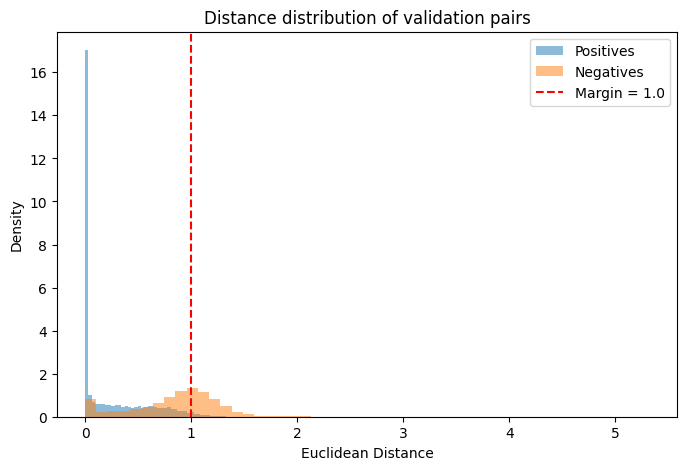

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(pos_dists, bins=50, alpha=0.5, label='Positives', density=True)
plt.hist(neg_dists, bins=50, alpha=0.5, label='Negatives', density=True)
plt.axvline(margin, color='r', linestyle='--', label=f'Margin = {margin}')
plt.xlabel('Euclidean Distance')
plt.ylabel('Density')
plt.legend()
plt.title('Distance distribution of validation pairs')
plt.show()

In [64]:
# For negatives (label=0), sort by distance ascending
neg_sort_indices = torch.argsort(neg_dists)
worst_neg_indices = torch.where(all_labels == 0)[0][neg_sort_indices[:20]]  # top 20 false positives

# Make sure val_df is the DataFrame that was used to create the Validation Dataset
# (it must contain the columns 'question1' and 'question2')

for global_idx in worst_neg_indices.tolist():
    row = val_df.iloc[global_idx]          # global_idx matches DataLoader order
    dist_val = all_dists[global_idx].item()
    print(f"Dist: {dist_val:.4f}")
    print(f"Q1: {row['question1']}")
    print(f"Q2: {row['question2']}")
    print("---")

Dist: 0.0000
Q1: how safe is it for dogs to eat licorice ? 
Q2: how safe is it for dogs to eat cantaloupe ? 
---
Dist: 0.0000
Q1: what is the value of cos9* ? 
Q2: what is the value of 100p2 ? 
---
Dist: 0.0000
Q1: is codingparks . com legit ? 
Q2: is zooqle . com legit ? 
---
Dist: 0.0000
Q1: what hotel in lambasingi hill - station would be safe for unmarried couples ,  without the harassment of police ,  hotel staff ,  and moral police ? 
Q2: what hotel in diphu hill - station would be safe for unmarried couples ,  without the harassment of police ,  hotel staff ,  and moral police ? 
---
Dist: 0.0000
Q1: who is jeff behkne ? 
Q2: who is jeff bozes ? 
---
Dist: 0.0000
Q1: what is sbcglobal . net ? 
Q2: what is joox . net ? 
---
Dist: 0.0000
Q1: what is the meaning of ‘anuraakam’ in malayalam ? 
Q2: what is the meaning of orapikka in malayalam ? 
---
Dist: 0.0000
Q1: what is a suitable solar panel installation provider near monrovia ,  california ca ? 
Q2: what is a suitable solar pan

In [68]:
with torch.no_grad():
    batch = next(iter(val_dataloader))
    q1 = batch['q1'].to(sys_cfg.DEVICE)
    h = model._encode(q1[:32])   # take a batch
    print("Variance per dimension:", h.var(dim=0).mean().item())

Variance per dimension: 0.0008716504089534283


In [70]:
import torch
import torch.nn.functional as F
import numpy as np

model.eval()
device = next(model.parameters()).device

threshold = 0.5457           # your optimal threshold
num_examples_to_show = 10    # how many false positives to print

batch = next(iter(val_dataloader))
q1 = batch['q1'].to(device)
q2 = batch['q2'].to(device)
labels = batch['label'].to(device)

with torch.no_grad():
    distances = model(q1, q2)
    probs = torch.exp(-distances)
    preds = (probs >= threshold).long()

    # False positives: predicted duplicate but label 0
    fp_mask = (preds == 1) & (labels == 0)
    fp_indices = torch.where(fp_mask)[0].cpu().tolist()

    if len(fp_indices) == 0:
        print("No false positives in this batch. Try another batch or lower threshold.")
    else:
        # Sort by distance ascending (worst first)
        fp_dists = distances[fp_indices].cpu()
        sorted_fp = sorted(zip(fp_indices, fp_dists), key=lambda x: x[1])

        for idx, (global_idx, dist_val) in enumerate(sorted_fp[:num_examples_to_show]):
            print(f"\n{'='*100}")
            print(f"Example {idx+1} | Distance: {dist_val:.6f} | Prob: {probs[global_idx]:.4f} | True label: 0")
            print()

            # Extract tokens
            q1_tokens = [idx2word.get(tok.item(), '<unk>') for tok in q1[global_idx]]
            q2_tokens = [idx2word.get(tok.item(), '<unk>') for tok in q2[global_idx]]

            # Get attention weights (use the helper from previous answer)
            ctx1, attn1 = get_attention_and_context(model, q1[global_idx:global_idx+1])
            ctx2, attn2 = get_attention_and_context(model, q2[global_idx:global_idx+1])

            # Print Q1
            print("Q1 tokens and attention:")
            for token, weight in zip(q1_tokens, attn1):
                if token != '[PAD]':   # skip padding tokens for brevity
                    print(f"  {token:25s} : {weight:.4f}")
            # Print Q2
            print("\nQ2 tokens and attention:")
            for token, weight in zip(q2_tokens, attn2):
                if token != '[PAD]':
                    print(f"  {token:25s} : {weight:.4f}")

    # ------------------------------------------------------------------
    # Also show a few true positives for contrast
    tp_mask = (preds == 1) & (labels == 1)
    tp_indices = torch.where(tp_mask)[0].cpu().tolist()
    if len(tp_indices) > 0:
        print("\n\n--- For contrast: a true positive (label=1, predicted 1) ---")
        sample_tp = tp_indices[0]   # first true positive
        q1_tokens_tp = [idx2word.get(tok.item(), '<unk>') for tok in q1[sample_tp]]
        q2_tokens_tp = [idx2word.get(tok.item(), '<unk>') for tok in q2[sample_tp]]
        ctx1_tp, attn1_tp = get_attention_and_context(model, q1[sample_tp:sample_tp+1])
        ctx2_tp, attn2_tp = get_attention_and_context(model, q2[sample_tp:sample_tp+1])
        print("Q1 tokens and attention:")
        for token, weight in zip(q1_tokens_tp, attn1_tp):
            if token != '[PAD]':
                print(f"  {token:25s} : {weight:.4f}")
        print("Q2 tokens and attention:")
        for token, weight in zip(q2_tokens_tp, attn2_tp):
            if token != '[PAD]':
                print(f"  {token:25s} : {weight:.4f}")

    # ------------------------------------------------------------------
    # Variance checks on the whole batch (first 64 samples to save time)
    with torch.no_grad():
        # LSTM output before attention
        emb = model.embedding(q1[:64])
        if model.config.LAYER_NORM_EMB: emb = model.emb_norm(emb)
        emb = model.emb_dropout(emb)
        lstm_out, _ = model.LSTM(emb)
        var_lstm = lstm_out.var(dim=[0,1]).mean().item()
        print(f"\nLSTM output variance (pre‑attention): {var_lstm:.6f}")

        # Final context vector variance
        h = model._encode(q1[:64])
        var_ctx = h.var(dim=0).mean().item()
        print(f"Context vector variance: {var_ctx:.6f}")


Example 1 | Distance: 0.000470 | Prob: 0.9995 | True label: 0

Q1 tokens and attention:
  what                      : 0.1723
  are                       : 0.1963
  the                       : 0.1963
  best                      : 0.1899
  ways                      : 0.1534
  to                        : 0.0607
  lose                      : 0.0257
  weight                    : 0.0043
  ?                         : 0.0011
  <PAD>                     : 0.0000
  <PAD>                     : 0.0000
  <PAD>                     : 0.0000
  <PAD>                     : 0.0000
  <PAD>                     : 0.0000
  <PAD>                     : 0.0000
  <PAD>                     : 0.0000
  <PAD>                     : 0.0000
  <PAD>                     : 0.0000
  <PAD>                     : 0.0000
  <PAD>                     : 0.0000
  <PAD>                     : 0.0000
  <PAD>                     : 0.0000
  <PAD>                     : 0.0000
  <PAD>                     : 0.0000
  <PAD>                

In [71]:
# True positives: predicted 1 and label 1
tp_mask = (preds == 1) & (labels == 1)
tp_indices = torch.where(tp_mask)[0]
if len(tp_indices) > 0:
    print("\n\n" + "="*100)
    print("TRUE POSITIVES (correctly predicted duplicates)")
    # Show first 5 TPs
    for idx, global_idx in enumerate(tp_indices[:5]):
        print(f"\n--- TP Example {idx+1} | Index: {global_idx.item()}")
        q1_tokens_tp = [idx2word.get(tok.item(), '<unk>') for tok in q1[global_idx]]
        q2_tokens_tp = [idx2word.get(tok.item(), '<unk>') for tok in q2[global_idx]]
        dist_tp = distances[global_idx].item()
        prob_tp = torch.exp(-distances[global_idx]).item()
        print(f"Distance: {dist_tp:.6f} | Prob: {prob_tp:.4f} | Label: 1")

        ctx1_tp, attn1_tp = get_attention_and_context(model, q1[global_idx:global_idx+1])
        ctx2_tp, attn2_tp = get_attention_and_context(model, q2[global_idx:global_idx+1])

        print("\nQ1 tokens and attention:")
        for token, weight in zip(q1_tokens_tp, attn1_tp):
            if token != '[PAD]':
                print(f"  {token:25s} : {weight:.4f}")

        print("\nQ2 tokens and attention:")
        for token, weight in zip(q2_tokens_tp, attn2_tp):
            if token != '[PAD]':
                print(f"  {token:25s} : {weight:.4f}")

else:
    print("\nNo true positives in this batch.")



TRUE POSITIVES (correctly predicted duplicates)

--- TP Example 1 | Index: 0
Distance: 0.000713 | Prob: 0.9993 | Label: 1

Q1 tokens and attention:
  how                       : 0.2409
  can                       : 0.2836
  i                         : 0.2136
  make                      : 0.0961
  money                     : 0.0655
  online                    : 0.0426
  in                        : 0.0412
  india                     : 0.0118
  ?                         : 0.0048
  <PAD>                     : 0.0000
  <PAD>                     : 0.0000
  <PAD>                     : 0.0000
  <PAD>                     : 0.0000
  <PAD>                     : 0.0000
  <PAD>                     : 0.0000
  <PAD>                     : 0.0000
  <PAD>                     : 0.0000
  <PAD>                     : 0.0000
  <PAD>                     : 0.0000
  <PAD>                     : 0.0000
  <PAD>                     : 0.0000
  <PAD>                     : 0.0000
  <PAD>                     : 0.0000

In [72]:
import nltk

In [73]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\98922\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True